# GPR Placed Above a Two-Layered Subsurface with Multiple Anomalies

In this notebook we will extend the two layered medium representation of the Earth to include two anomalies: a sphere and a box of different dielectric properties. Its solution is compared against the two-layered semi-analytica reference solution, not to measure accuracy, but to measure anomaly signature. ()

## 1. Imports, Path and Platform Configuration

These imports to the I/O module, the path and platform configurations are similar to the first example.

In [ ]:
import os
from pathlib import Path

# inputs
from elfe3d_gpr_io.inputs.survey import GPRSurvey
from elfe3d_gpr_io.inputs.anomalies import SphereAnomaly, BoxAnomaly

# runner
from elfe3d_gpr_io.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr_io.outputs.fieldreader import AnalyticalLoader, ElfeLoader
from elfe3d_gpr_io.outputs.visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot, ErrorHistogramPlot)

MASTER_PATH = (Path("..") / "elfe3D_GPR").resolve()

paths = ProjectPaths(
    master_dir = MASTER_PATH,
    exec_rel   = "",
    use_wsl    = False,
)

# Prints to verify that the paths are correct.
# print('Solver root:', MASTER_PATH)
# print('Executable:', paths.exec_path())


## 2: Generating the Geophysical Model

We will use a similar geometrical model as the third example notebook, except add a sphere anomaly and a new box anomaly with a dielectric contrast.

The sphere is buried such that its centre is located at coordinates $(0.75, 0.0, -0.5)$ m. It has a radius of $\lambda_{air}/20$ m, a relative electric permittivity $\varepsilon_r$ of $9$, electrical conductivity $\sigma$ of $5e\text{-}3$ S/m, and is non-magnetic. 

The box is buried between lateral extents of $(0, \lambda_{air}/8)$ m and $(-\lambda_{air}/20, \lambda_{air}/20)$ m and between depths $(0.9, 0.5)$ m. It has a relative electric permittivity $\varepsilon_r$ of $9$, electrical conductivity $\sigma$ of $1e\text{-}4$ S/m, and is non-magnetic. 

In [11]:
f    = 100e6
wave = 3e8 / f

survey = GPRSurvey.build(
    experiment_name="AnomaliesMixed",
    base_dir=MASTER_PATH,

    # Domain
    x_e=[-wave/10, 1 + wave/10],
    y_e=[-wave/10, wave/10],
    z_e=[-1.0 - wave/10/3, wave/10],

    # Materials — air + 2 earth layers
    air_eps_r=1.0,
    air_sigma=1e-16,
    layer_thicknesses=[1.0, wave/10/3],
    layer_eps_r=[4.0, 9.0],
    layer_sigma=[1e-4, 1e-3],
    layer_mu_r=[1.0, 1.0],
    layer_sigma_m=[0.0, 0.0],

    # Mixed anomaly list: box (marker 101) + sphere (marker 102)
    anomalies=[
        BoxAnomaly(
            x=(0, wave/8),
            y=(-wave/20, wave/20),
            z=(-0.9, -0.5),
            properties=(9, 1e-4, 1.0, 0.0),
        ),
        SphereAnomaly(
            center=(0.75, 0.0, -0.5),
            radius=wave/20,
            properties=(9, 5e-3, 1.0, 0.0),
        ),
    ],

    # Source
    f_list=[f],
    antenna_position=[0.0, 0.0, 0.025],
    source_type=6,
    current_direction=1,
    num_segments=1,
    s_f=250,
    m=5,

    # Receivers
    num_receivers_inline=48,
    num_receivers_endfire=0,
    num_receivers_oblique=0,

    # Solver
    solver_type=2,
    max_ref_steps=0,
    max_unknowns=5_000_000,
    accuracy_tol=3e-5,
    output_fields_vtk=1,

    # PML
    num_pml_layers=1,
    pml_layer_thickness=wave/10,
    pml_type="lin",
    pml_decay_type=1,

    least_samples_per_wavelength=10,
)

survey.generate()
# print('poly :', survey.io.poly_file)


Source antenna length: 0.0006 m
Receiver antenna depth: -0.00015 m
Input generation complete.


## 3. Mesh generation with `tetgen`

In [12]:
run_tetgen(paths, survey.io.poly_file)

Opening GPR_model_AnomaliesMixed.poly.
Delaunizing vertices...
Delaunay seconds:  0.015541
Creating surface mesh ...
Surface mesh seconds:  0.003765
Constrained Delaunay...
Constrained Delaunay seconds:  0.01063
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000917
Refining mesh...
Refinement seconds:  1.07906
Optimizing mesh...
Optimization seconds:  0.046034

Writing GPR_model_AnomaliesMixed.1.node.
Writing GPR_model_AnomaliesMixed.1.ele.
Writing GPR_model_AnomaliesMixed.1.face.
Writing GPR_model_AnomaliesMixed.1.edge.
Writing GPR_model_AnomaliesMixed.1.vtk.
Writing GPR_model_AnomaliesMixed.1.neigh.

Output seconds:  0.971984
Total running seconds:  2.12818

Statistics:

  Input points: 2812
  Input facets: 5253
  Input segments: 8061
  Input holes: 0
  Input regions: 47

  Mesh points: 56345
  Mesh tetrahedra: 341716
  Mesh faces: 686899
  Mesh edges: 401527
  Mesh faces on facets: 40628
  Mesh edges on segments: 9666
  Steiner points

## 4. Run the Fortran solver

We now have all simulation inputs ready. Hence, we can run the simulation now.

In [ ]:
run_solver(paths,survey)

## 5. Load solver results
Once the simulation is completed running, `elfe3d_gpr_io` can read the results.

In [ ]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
# print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR',
    num_endfire = 48,
).endfire()

print(f'r : {ef.r.min():.3f} - {ef.r.max():.3f} m ({len(ef.r)} receivers)')


r : 0.100 - 1.000 m (48 receivers)


## 6. Background two-layered medium solution reference

In [ ]:
ANALYTICAL_DIR = (Path("..") / "data"/ "data_semi_analytical").resolve()    # Directory for where to find the analytical reference data.

semi_analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_4_9_100MHz_NR.csv'),
    label='Semi-Analytical',
).endfire()


## 7. Compare computed field to analytical reference

### 7.1. Plotting the base receiver-line data against analytical solution

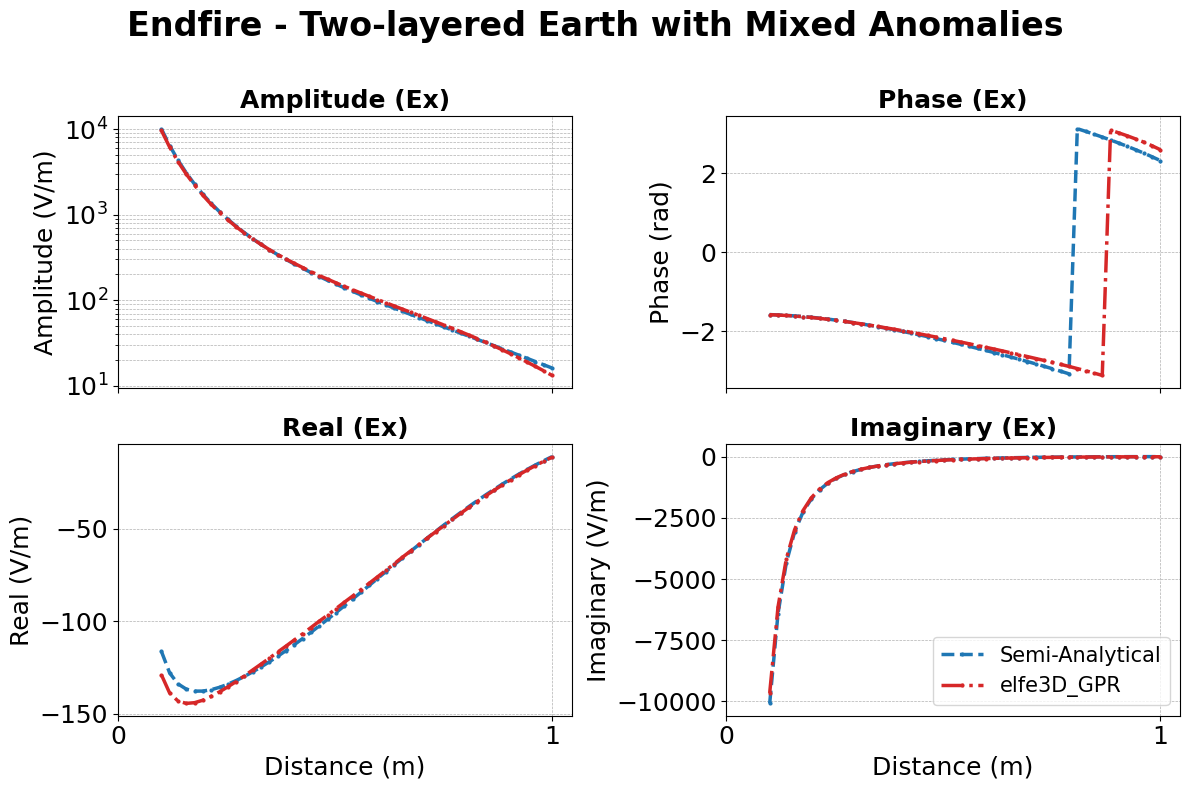

In [ ]:
ReceiverLinePlot([semi_analytical, ef]).plot(suptitle="Endfire - Two-layered Earth with Mixed Anomalies")

The figure shows how the anomalous structures produce a significant phase change compared to the two-layered solution. The real part and the amplitude also show slight deviations unlike the numerical approximation errors in the third example notebook.

### 7.2. Anomaly response (difference from background)

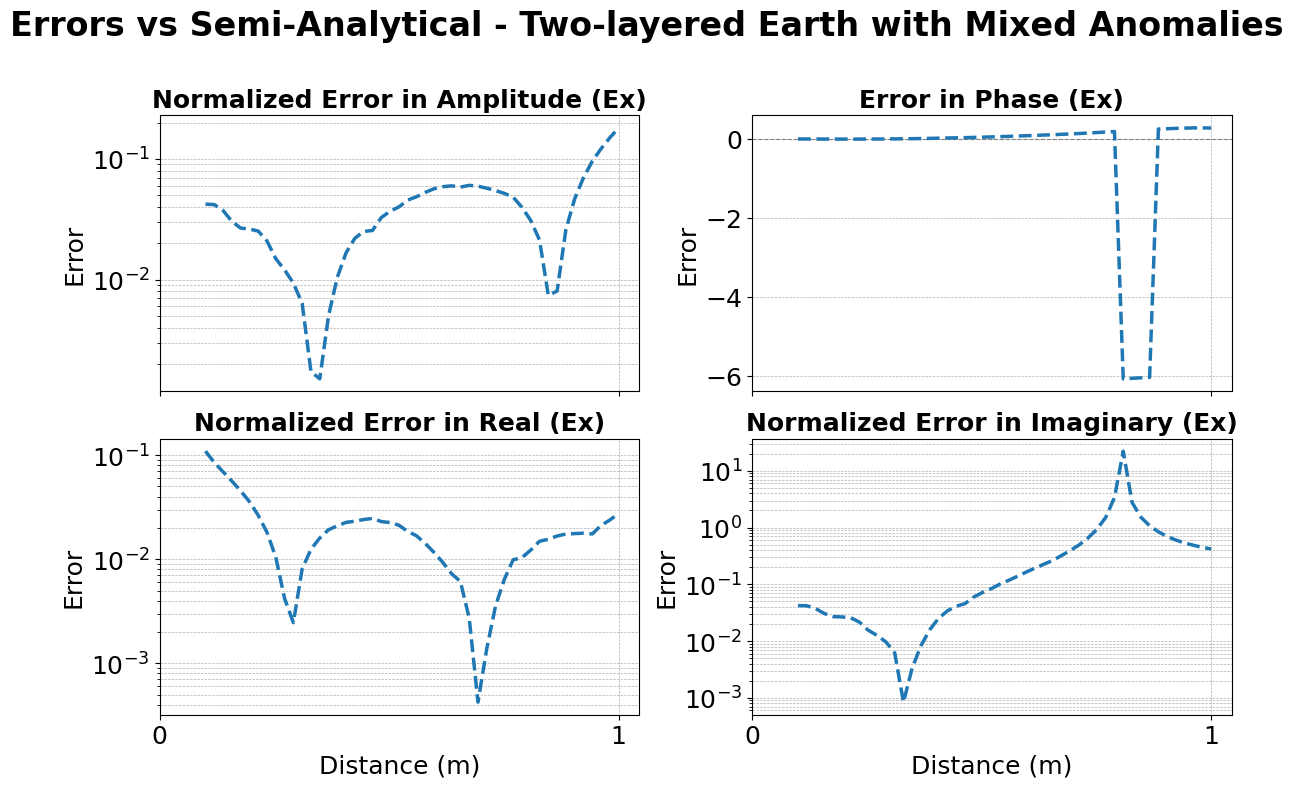

In [ ]:
ReceiverLineErrorPlot([ef], reference=semi_analytical).plot(suptitle="Errors vs Semi-Analytical - Two-layered Earth with Mixed Anomalies")

### 7.3. Error distribution histogram

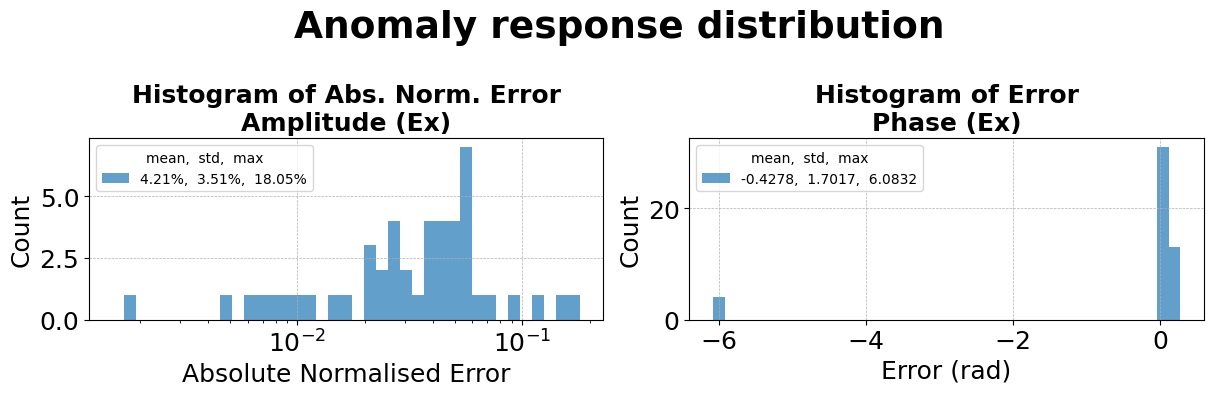

In [ ]:
ErrorHistogramPlot([ef], reference=semi_analytical).plot(suptitle='Anomaly response distribution')


It is clearer from the histogram of amplitude errors that the signature from the two anomalies is indeed present - as the mean and max errors are substantially higher than the numerical errors in the third example notebook.

## 8. Conclusions

With this notebook, we demonstrated how `elfe3D_GPR` can work with a more complex subsurface model and use the error post-processing functions to estimate anomaly signatures.